     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 9.8 MB/s eta 0:00:00:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 68.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 4.6 MB/s eta 0:00:00
  Created wheel for wordninja: filename=wordninja-2.0.0-py3-none-any.whl size=541530 sha256=325e7d5a8ed9d25b8973f3a3de09487bd5113bd7a8f8dc8933a0e7978ba906a2
  Stored in directory: /root/.cache/pip/wheels/aa/44/3a/f2a5c1859b8b541ded969b4cd12d0a58897f12408f4f51e084
Successfully built wordninja
Loading dataset...
Dataset loaded with shape: (232074, 2)
                           

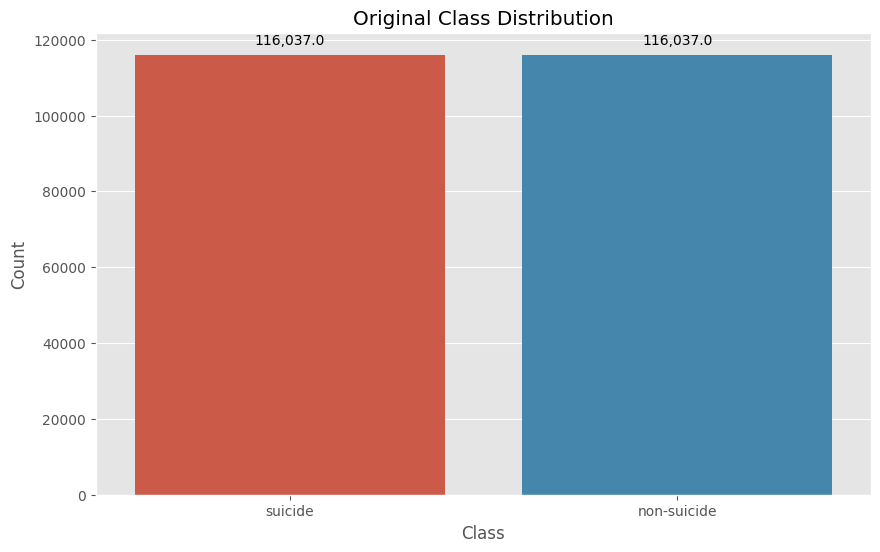


Sample of preprocessed text:

Original Text 1:
Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse t...

Cleaned Text 1:
sex wife threaten suicide recently leave wife good cheat twice lie decide refuse day ago begin threaten suicide tirelessly spend day talk keep hesitat...
--------------------------------------------------------------------------------

Original Text 2:
Am I weird I don't get affected by compliments if it's coming from someone I know irl but I feel really good when internet strangers do it...

Cleaned Text 2:
weird not affect compliment come know girl but feel good internet stranger...
--------------------------------------------------------------------------------

Original Text 3:
Finally 2020 is almost over... So I can never hear "2020 has been a bad year" ever again. I swear to fucking God it's so annoying...

Cleaned Text 3:
finally never hear bad year swear fucking 

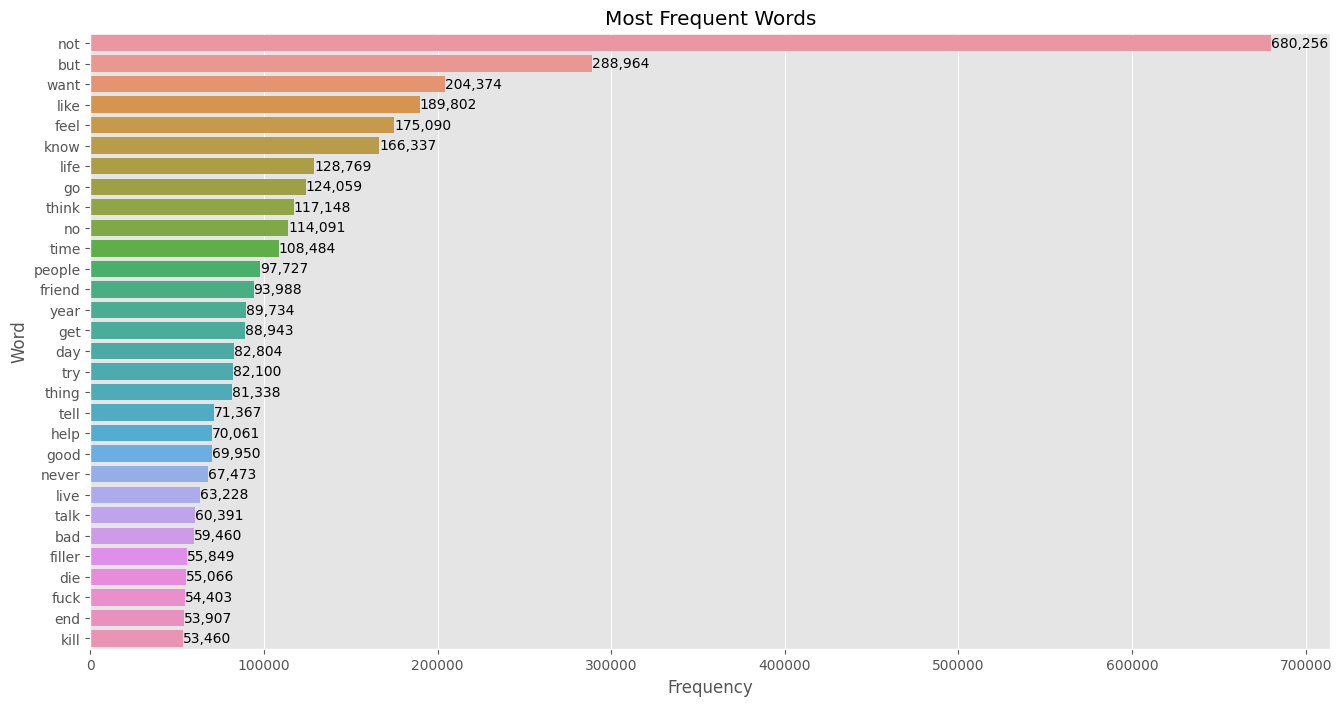


Generating word clouds for each class...


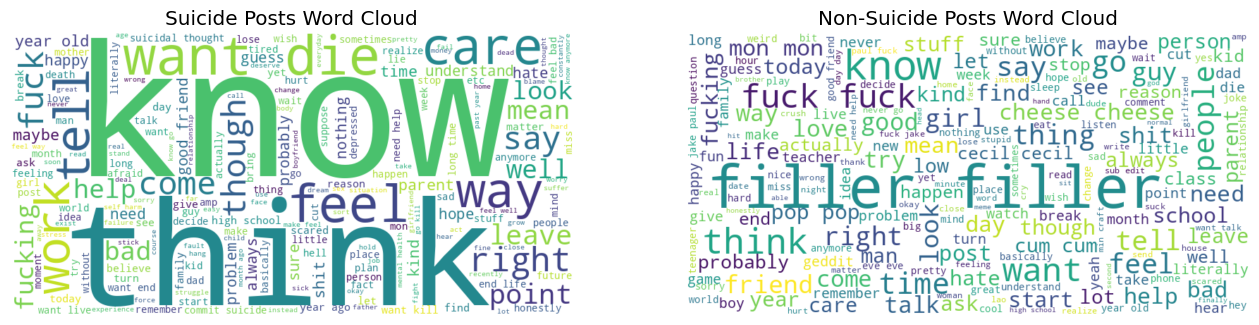


Analyzing text length...


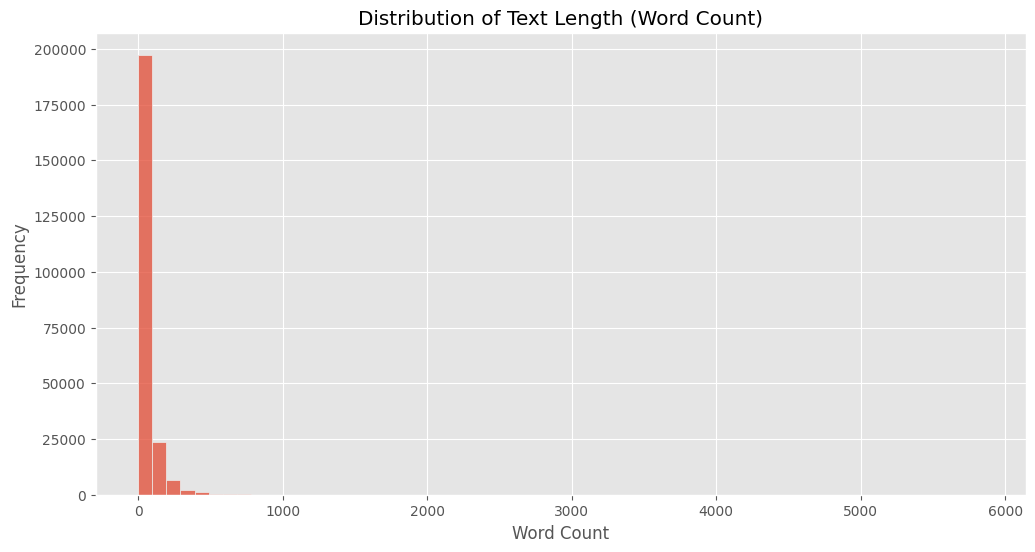


Text length statistics:
count    231933.000000
mean         54.275398
std          90.838406
min           1.000000
25%          12.000000
50%          26.000000
75%          63.000000
max        5850.000000
dtype: float64

Filtering texts with word count <= 139...
Removed 20477 outlier rows

Class distribution before balancing:
class
non-suicide    113729
suicide         97727
Name: count, dtype: int64

Balancing the dataset...

Class distribution after balancing:
class
non-suicide    97727
suicide        97727
Name: count, dtype: int64


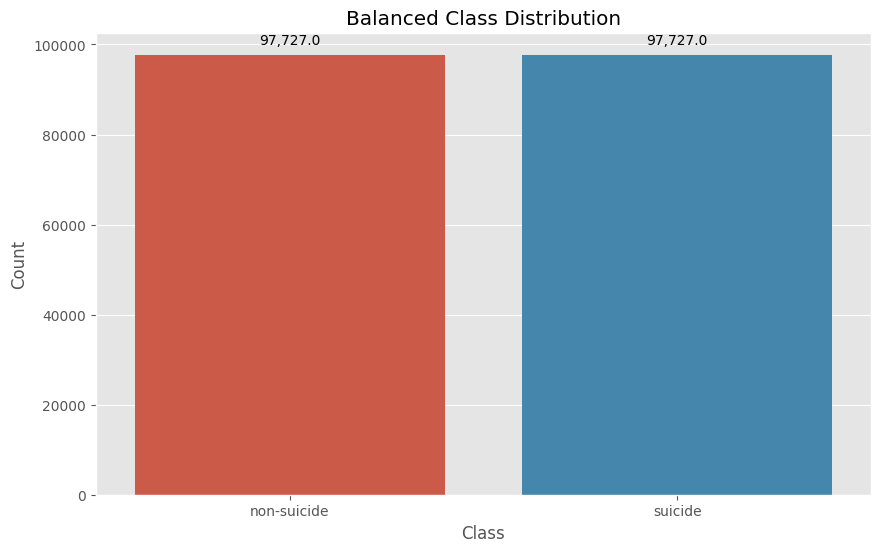

<Figure size 1200x700 with 0 Axes>

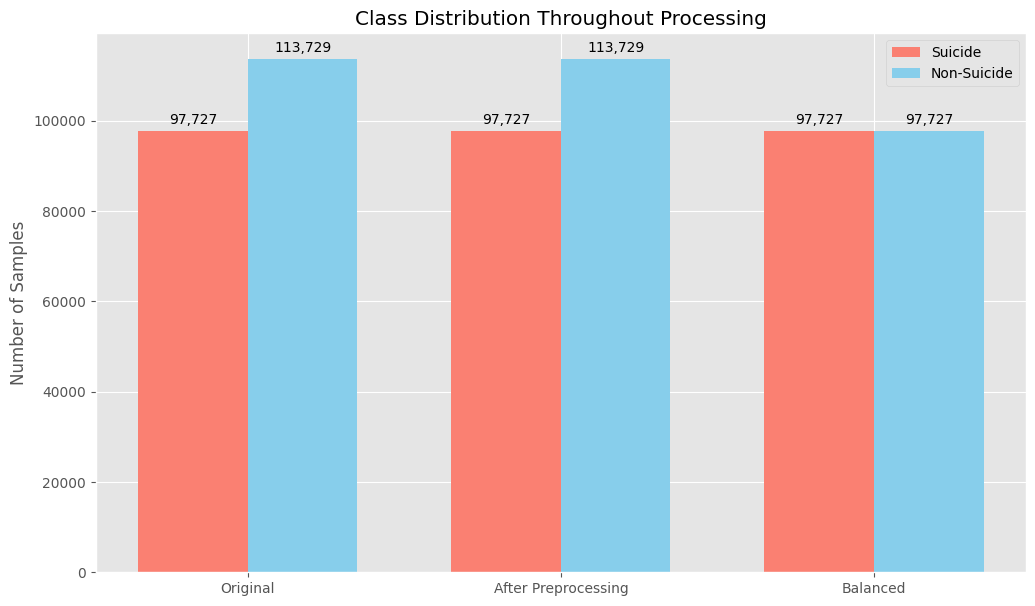

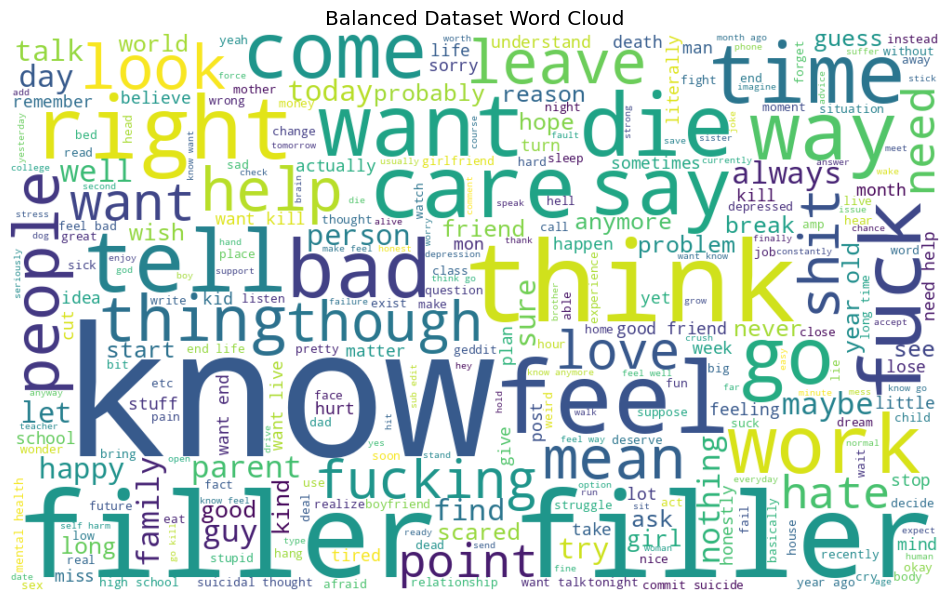

Saved to /kaggle/working/suicide_detection_results_20250408_152844/suicide_detection_preprocessed.csv
Saved to /kaggle/working/suicide_detection_results_20250408_152844/suicide_detection_balanced_cleaned.csv


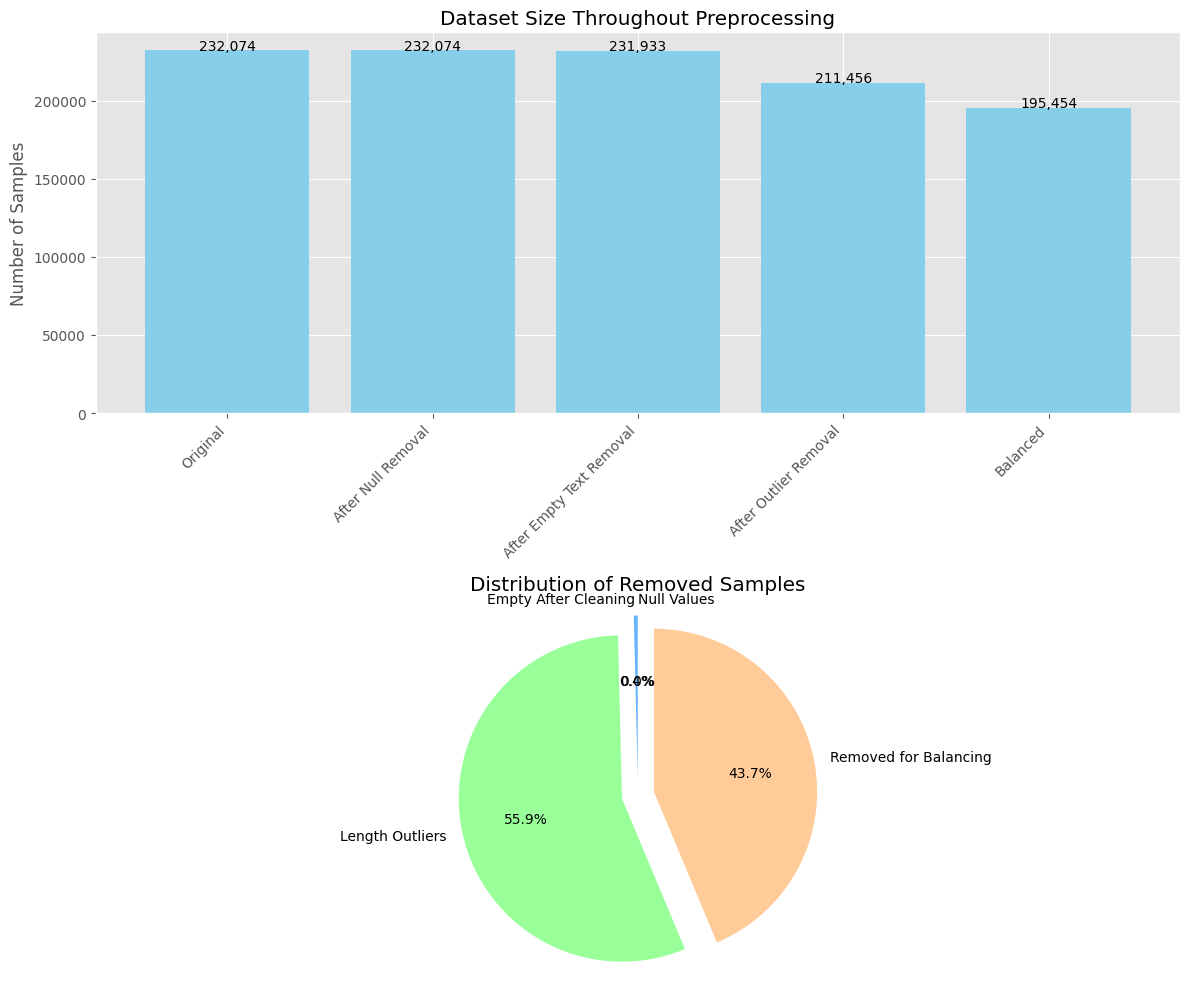

PREPROCESSING COMPLETE

Summary of preprocessing and cleaning steps:
1. Loaded dataset with original shape: (232074, 2)
2. Removed 0 rows with null text values
3. Applied comprehensive text preprocessing:
   - Removed accented characters, URLs, symbols, digits
   - Expanded contractions
   - Fixed word lengthening
   - Applied spell checking
   - Tokenized and lemmatized text
   - Removed stopwords (preserving important negation words)
4. Removed 141 rows with empty text after preprocessing
5. Removed outliers based on text length > 139 (20477 rows removed)
6. Balanced dataset to have equal class distribution: 97727 samples per class

Final balanced dataset shape: (195454, 3)

All results and visualizations have been saved to: /kaggle/working/suicide_detection_results_20250408_152844/

Preprocessed dataset available at: /kaggle/working/suicide_detection_results_20250408_152844/suicide_detection_preprocessed.csv
Final balanced dataset available at: /kaggle/working/suicide_detection_resu

In [1]:
# Install required packages if needed
!pip install unidecode contractions spacy wordninja pyspellchecker symspellpy tensorflow wordcloud

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import collections
import warnings
import os
from datetime import datetime
from wordcloud import WordCloud
from sklearn.utils import resample
warnings.filterwarnings('ignore')  # Suppress warnings

# For text preprocessing
import spacy
import unidecode
import contractions
from spellchecker import SpellChecker
from symspellpy import SymSpell, Verbosity

# Use tensorflow's implementation of Tokenizer
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
except ImportError:
    # Alternative implementation if tensorflow is not available
    class Tokenizer:
        def __init__(self):
            self.word_counts = {}
            
        def fit_on_texts(self, texts):
            """Simple implementation to count word frequencies"""
            for text in texts:
                if pd.isna(text):
                    continue
                words = str(text).split()
                for word in words:
                    if word in self.word_counts:
                        self.word_counts[word] += 1
                    else:
                        self.word_counts[word] = 1
            
            # Sort by frequency
            self.word_counts = dict(sorted(self.word_counts.items(), 
                                           key=lambda item: item[1], 
                                           reverse=True))

# For visualization
plt.style.use('ggplot')

# Define output directory structure
input_file_path = '/kaggle/input/suicide-watch/Suicide_Detection.csv'
output_directory = '/kaggle/working/'

# Create timestamp for unique output folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"{output_directory}suicide_detection_results_{timestamp}/"

# Create directory if it doesn't exist
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Function to save and display figures
def save_and_display_figure(fig, filename):
    """Save matplotlib figure to PNG file and display it in the notebook"""
    # Save in results directory with organized filename
    filepath = f"{results_dir}{filename}.png"
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    
    # Display in notebook
    plt.show()
    
    # Return filepath for reference
    return filepath

# Function to save data files
def save_data_file(df, filename):
    """Save dataframe to CSV file in the results directory"""
    # Remove any unnamed columns before saving
    df_to_save = df.copy()
    unnamed_cols = [col for col in df_to_save.columns if 'Unnamed:' in col]
    if unnamed_cols:
        df_to_save = df_to_save.drop(columns=unnamed_cols)
    
    # Save in results directory
    filepath = f"{results_dir}{filename}.csv"
    df_to_save.to_csv(filepath, index=False)
    print(f"Saved to {filepath}")
    
    # Return filepath for reference
    return filepath

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
except:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Initialize SymSpell for spell checking - with robust error handling
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

try:
    # Using importlib instead of deprecated pkg_resources
    import importlib.resources as pkg_resources
    from symspellpy import symspellpy  # The package containing the resource
    
    with pkg_resources.path(symspellpy, "frequency_dictionary_en_82_765.txt") as dictionary_path:
        with pkg_resources.path(symspellpy, "frequency_bigramdictionary_en_243_342.txt") as bigram_path:
            sym_spell.load_dictionary(str(dictionary_path), term_index=0, count_index=1)
            sym_spell.load_bigram_dictionary(str(bigram_path), term_index=0, count_index=2)
except:
    # Fallback method if the above doesn't work
    try:
        import symspellpy
        base_path = os.path.dirname(symspellpy.__file__)
        dictionary_path = os.path.join(base_path, "frequency_dictionary_en_82_765.txt")
        bigram_path = os.path.join(base_path, "frequency_bigramdictionary_en_243_342.txt")
        
        sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
        sym_spell.load_bigram_dictionary(bigram_path, term_index=0, count_index=2)
    except Exception as e:
        print(f"Error loading SymSpell dictionaries: {e}")
        print("Spell checking will be disabled")
        
# Initialize vocabulary counter
vocab = collections.Counter()

# Load dataset
print("Loading dataset...")
df = pd.read_csv(input_file_path)

# Remove index or unnamed columns if present
if 'index' in df.columns:
    df = df.drop('index', axis=1)
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Save original dataset shape info
original_shape = df.shape
print(f"Dataset loaded with shape: {original_shape}")
print(df.head())

# Check for null values in the text column
null_count = df['text'].isnull().sum()
print(f"\nNumber of null values in text column: {null_count}")

# Remove null values
if null_count > 0:
    print(f"Removing {null_count} rows with null text values")
    df = df.dropna(subset=['text'])
    print(f"Dataset shape after removing null values: {df.shape}")

# Check class distribution
class_counts = df['class'].value_counts()
print("\nOriginal class distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='class', data=df)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

# Save and display figure
save_and_display_figure(plt.gcf(), "01_original_class_distribution")

# Define text preprocessing functions
# Spell Check using SymSpell
def fix_spelling(text):
    try:
        suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
        if suggestions:
            corrected_text = suggestions[0].term  # get the first suggestion
            return corrected_text
    except Exception as e:
        # If any error occurs during spell checking, return the original text
        print(f"Spell checking error: {e}")
    return text

# Important words to keep (not remove as stopwords)
deselect_stop_words = ["not", "no", "never", "always", "none", "nothing",
                       "nor", "cannot", "without", "against", "unless", "but", 
                       "however", "although", "though", "yet", "perhaps", 
                       "maybe", "sometimes", "often", "always", "never"]

# Remove these from stopwords list
for w in deselect_stop_words:
    nlp.vocab[w].is_stop = False

# Remove extra whitespaces from text
def remove_whitespace(text):
    text = text.strip()
    return " ".join(text.split())

# Remove accented characters from text, e.g. café
def remove_accented_chars(text):
    text = unidecode.unidecode(text)
    return text

# Remove URL
def remove_url(text):
    return re.sub(r'http\S+', '', text)

# Removing symbols and digits
def remove_symbols_digits(text):
    return re.sub('[^a-zA-Z\s]', ' ', text)

# Removing special characters
def remove_special(text):
    return text.replace("\r", " ").replace("\n", " ").replace("    ", " ").replace('"', '')

# Fix word lengthening (characters are wrongly repeated)
def fix_lengthening(text):
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

# Main preprocessing function
def text_preprocessing(text, accented_chars=True, contractions_expansion=True, convert_num=True,
                       extra_whitespace=True, lemmatization=True, lowercase=True,
                       url=True, symbols_digits=True, special_chars=True,
                       stop_words=True, lengthening=True, spelling=True):
    """preprocess text with default option set to true for all steps"""
    
    # Handle NaN values
    if pd.isna(text):
        return ""
        
    # Convert to string if not already
    text = str(text)
    
    if accented_chars:  # remove accented characters
        text = remove_accented_chars(text)
    if contractions_expansion:  # expand contractions
        text = contractions.fix(text)
    if lowercase:  # convert all characters to lowercase
        text = text.lower()
    if url:  # remove URLs before removing symbols
        text = remove_url(text)
    if symbols_digits:  # remove symbols and digits
        text = remove_symbols_digits(text)
    if special_chars:  # remove special characters
        text = remove_special(text)
    if extra_whitespace:  # remove extra whitespaces
        text = remove_whitespace(text)
    if lengthening:  # fix word lengthening
        text = fix_lengthening(text)
    if spelling:  # fix spelling
        text = fix_spelling(text)

    doc = nlp(text)  # tokenize text

    clean_text = []

    for token in doc:
        flag = True
        edit = token.text
        # remove stop words
        if stop_words and token.is_stop and token.pos_ != 'NUM':
            flag = False
        # exclude number words
        if convert_num and token.pos_ == 'NUM' and flag:
            flag = False
        # convert tokens to base form
        elif lemmatization and token.lemma_ != "-PRON-" and flag:
            edit = token.lemma_
        # append tokens edited and not removed to list
        if edit != "" and flag:
            clean_text.append(edit)
    return " ".join(clean_text)

# Process a small sample for demonstration
sample_size = 5
sample_df = df.head(sample_size).copy()
sample_df['cleaned_text'] = sample_df['text'].apply(lambda row: text_preprocessing(row))

# Display sample of preprocessed text
print("\nSample of preprocessed text:")
for i, row in sample_df.iterrows():
    print(f"\nOriginal Text {i+1}:\n{row['text'][:150]}...")
    print(f"\nCleaned Text {i+1}:\n{row['cleaned_text'][:150]}...")
    print("-" * 80)

# Process full dataset in batches
print("\nStarting text preprocessing...")

batch_size = 5000  # Adjust based on your memory constraints
num_batches = len(df) // batch_size + (1 if len(df) % batch_size > 0 else 0)

print(f"Processing {len(df)} rows in {num_batches} batches...")

processed_results = []
for i in range(num_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(df))
    
    print(f"Processing batch {i+1}/{num_batches} (rows {start_idx} to {end_idx})...")
    
    # Process this batch
    batch = df.iloc[start_idx:end_idx].copy()
    batch['cleaned_text'] = batch['text'].apply(lambda row: text_preprocessing(row))
    processed_results.append(batch)

# Combine all processed batches
df = pd.concat(processed_results, ignore_index=True)

# Remove any unnamed columns that might have been introduced
unnamed_cols = [col for col in df.columns if 'Unnamed:' in col]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
    
print("Text preprocessing completed")

# Check for empty text after preprocessing
empty_text_count = df['cleaned_text'].apply(lambda x: len(str(x).split()) == 0).sum()
print(f"\nNumber of rows with empty text after preprocessing: {empty_text_count}")

# Remove empty rows
if empty_text_count > 0:
    print(f"Removing {empty_text_count} rows with empty text after preprocessing")
    df = df[df['cleaned_text'].apply(lambda x: len(str(x).split()) > 0)]
    print(f"Dataset shape after removing empty rows: {df.shape}")

# Analyze word frequency
print("\nAnalyzing word frequency...")

# Create tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['cleaned_text'])

# Get word counts
word_freq = pd.DataFrame(tokenizer.word_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

# Display top 20 most frequent words
print("\nTop 20 most frequent words:")
print(word_freq.head(20))

# Plot top words
plt.figure(figsize=(16, 8))
ax = sns.barplot(x='count', y='word', data=word_freq.head(30))
plt.title('Most Frequent Words')
plt.xlabel("Frequency")
plt.ylabel("Word")

# Add count labels
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2, f'{int(width):,}', 
            ha='left', va='center')

# Save and display figure
save_and_display_figure(plt.gcf(), "02_most_frequent_words")

# Generate word clouds for each class
print("\nGenerating word clouds for each class...")

# Create word clouds for each class
plt.figure(figsize=(16, 8))

# Split by class
suicide_texts = ' '.join(df[df['class'] == 'suicide']['cleaned_text'])
non_suicide_texts = ' '.join(df[df['class'] == 'non-suicide']['cleaned_text'])

# Generate word clouds
plt.subplot(1, 2, 1)
wordcloud_suicide = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    max_words=200,
    contour_width=3,
    contour_color='steelblue'
).generate(suicide_texts)

plt.imshow(wordcloud_suicide, interpolation='bilinear')
plt.title('Suicide Posts Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_non_suicide = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    max_words=200,
    contour_width=3,
    contour_color='forestgreen'
).generate(non_suicide_texts)

plt.imshow(wordcloud_non_suicide, interpolation='bilinear')
plt.title('Non-Suicide Posts Word Cloud')
plt.axis('off')

# Save and display figure
save_and_display_figure(plt.gcf(), "03_class_word_clouds")

# Analyze text length
print("\nAnalyzing text length...")
posts_len = [len(str(x).split()) for x in df['cleaned_text']]

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.histplot(posts_len, bins=60)
plt.title('Distribution of Text Length (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

# Save and display figure
save_and_display_figure(plt.gcf(), "04_text_length_distribution")

# Get descriptive statistics
length_stats = pd.Series(posts_len).describe()
print("\nText length statistics:")
print(length_stats)

# Remove outliers based on text length
cutoff_length = int(length_stats['75%'] + 1.5 * (length_stats['75%'] - length_stats['25%']))
print(f"\nFiltering texts with word count <= {cutoff_length}...")

before_outlier_removal = len(df)
df = df[df['cleaned_text'].apply(lambda x: len(str(x).split()) <= cutoff_length)]
df.reset_index(drop=True, inplace=True)
after_outlier_removal = len(df)
print(f"Removed {before_outlier_removal - after_outlier_removal} outlier rows")

# Check the final class distribution before balancing
final_class_counts = df['class'].value_counts()
print("\nClass distribution before balancing:")
print(final_class_counts)

# Balance the dataset by downsampling the majority class
print("\nBalancing the dataset...")
df_majority = df[df['class'] == final_class_counts.idxmax()]
df_minority = df[df['class'] == final_class_counts.idxmin()]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Combine the downsampled majority class with the minority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the balanced class distribution
balanced_class_counts = df_balanced['class'].value_counts()
print("\nClass distribution after balancing:")
print(balanced_class_counts)

# Plot balanced class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='class', data=df_balanced)
plt.title('Balanced Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

# Save and display figure
save_and_display_figure(plt.gcf(), "05_balanced_class_distribution")

# Create a comparison of before and after balancing
plt.figure(figsize=(12, 7))

# Data for plotting
datasets = ['Original', 'After Preprocessing', 'Balanced']
suicide_counts = [
    df['class'].value_counts().get('suicide', 0) if 'suicide' in df['class'].unique() else 0,
    final_class_counts.get('suicide', 0),
    balanced_class_counts.get('suicide', 0)
]
non_suicide_counts = [
    df['class'].value_counts().get('non-suicide', 0) if 'non-suicide' in df['class'].unique() else 0,
    final_class_counts.get('non-suicide', 0),
    balanced_class_counts.get('non-suicide', 0)
]

# Set up the plot
x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
suicide_bars = ax.bar(x - width/2, suicide_counts, width, label='Suicide', color='salmon')
non_suicide_bars = ax.bar(x + width/2, non_suicide_counts, width, label='Non-Suicide', color='skyblue')

ax.set_title('Class Distribution Throughout Processing')
ax.set_ylabel('Number of Samples')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()

# Add count labels on bars
for bars in [suicide_bars, non_suicide_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height):,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Save and display figure
save_and_display_figure(plt.gcf(), "06_dataset_distribution_comparison")

# Generate word cloud for the balanced dataset
plt.figure(figsize=(12, 8))
all_text = ' '.join(df_balanced['cleaned_text'])
wordcloud_balanced = WordCloud(
    width=1000, 
    height=600,
    background_color='white',
    max_words=300,
    contour_width=3,
    contour_color='steelblue'
).generate(all_text)

plt.imshow(wordcloud_balanced, interpolation='bilinear')
plt.title('Balanced Dataset Word Cloud')
plt.axis('off')

# Save and display figure
save_and_display_figure(plt.gcf(), "07_balanced_dataset_word_cloud")

# Save the preprocessed dataset before balancing (without displaying in notebook)
preprocessed_file_path = save_data_file(df, "suicide_detection_preprocessed")

# Save the balanced preprocessed data (without displaying in notebook)
balanced_file_path = save_data_file(df_balanced, "suicide_detection_balanced_cleaned")

# Create a summary visualization with key preprocessing metrics
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
metrics = ['Original', 'After Null Removal', 'After Empty Text Removal', 'After Outlier Removal', 'Balanced']
values = [original_shape[0], original_shape[0] - null_count, original_shape[0] - null_count - empty_text_count, after_outlier_removal, len(df_balanced)]
plt.bar(metrics, values, color='skyblue')
plt.title('Dataset Size Throughout Preprocessing')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(values):
    plt.text(i, v + 500, f"{v:,}", ha='center')

plt.subplot(2, 1, 2)
labels = ['Null Values', 'Empty After Cleaning', 'Length Outliers', 'Removed for Balancing']
sizes = [null_count, empty_text_count, before_outlier_removal - after_outlier_removal, 
         final_class_counts.max() - final_class_counts.min()]
explode = (0.1, 0.1, 0.1, 0.1)
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.axis('equal')
plt.title('Distribution of Removed Samples')

plt.tight_layout()

# Save and display figure
save_and_display_figure(plt.gcf(), "08_preprocessing_summary")

# Print final summary
print("=" * 80)
print("PREPROCESSING COMPLETE")
print("=" * 80)
print("\nSummary of preprocessing and cleaning steps:")
print(f"1. Loaded dataset with original shape: {original_shape}")
print(f"2. Removed {null_count} rows with null text values")
print("3. Applied comprehensive text preprocessing:")
print("   - Removed accented characters, URLs, symbols, digits")
print("   - Expanded contractions")
print("   - Fixed word lengthening")
print("   - Applied spell checking")
print("   - Tokenized and lemmatized text")
print("   - Removed stopwords (preserving important negation words)")
print(f"4. Removed {empty_text_count} rows with empty text after preprocessing")
print(f"5. Removed outliers based on text length > {cutoff_length} ({before_outlier_removal - after_outlier_removal} rows removed)")
print(f"6. Balanced dataset to have equal class distribution: {balanced_class_counts['suicide']} samples per class")
print(f"\nFinal balanced dataset shape: {df_balanced.shape}")
print(f"\nAll results and visualizations have been saved to: {results_dir}")
print(f"\nPreprocessed dataset available at: {preprocessed_file_path}")
print(f"Final balanced dataset available at: {balanced_file_path}")
print("\nGenerated PNG files:")
for i in range(1, 9):
    filename = f"{i:02d}_{'class_word_clouds' if i==3 else 'preprocessing_summary' if i==8 else 'original_class_distribution' if i==1 else 'most_frequent_words' if i==2 else 'text_length_distribution' if i==4 else 'balanced_class_distribution' if i==5 else 'dataset_distribution_comparison' if i==6 else 'balanced_dataset_word_cloud'}"
    print(f"- {results_dir}{filename}.png")

Dataset Balancing****

Directory /kaggle/working/dataset_balancing/ already exists. Files may be overwritten.
DATASET BALANCING
Loading preprocessed dataset...
UTF-8 encoding failed, trying with latin-1 encoding...
Successfully loaded with latin-1 encoding
Dataset loaded with shape: (211468, 3)
First few rows:
                                                text        class  \
0  Ex Wife Threatening SuicideRecently I left my ...      suicide   
1  Am I weird I don't get affected by compliments...  non-suicide   
2  Finally 2020 is almost over... So I can never ...  non-suicide   
3          i need helpjust help me im crying so hard      suicide   
4  Honetly idkI dont know what im even doing here...      suicide   

                                        cleaned_text  
0  sex wife threaten suicide recently leave wife ...  
1  weird not affect compliment come know girl but...  
2  finally never hear bad year swear fucking god ...  
3                            need help help cry hard  
4  honestly d not kno

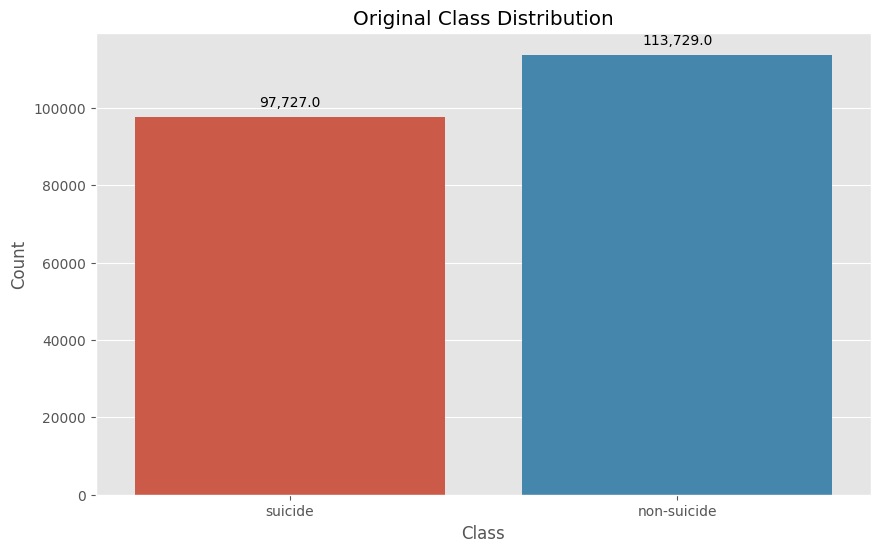


Balancing the dataset...
Majority class 'non-suicide': 113729 samples
Minority class 'suicide': 97727 samples

Class distribution after balancing:
class
non-suicide    97727
suicide        97727
Name: count, dtype: int64


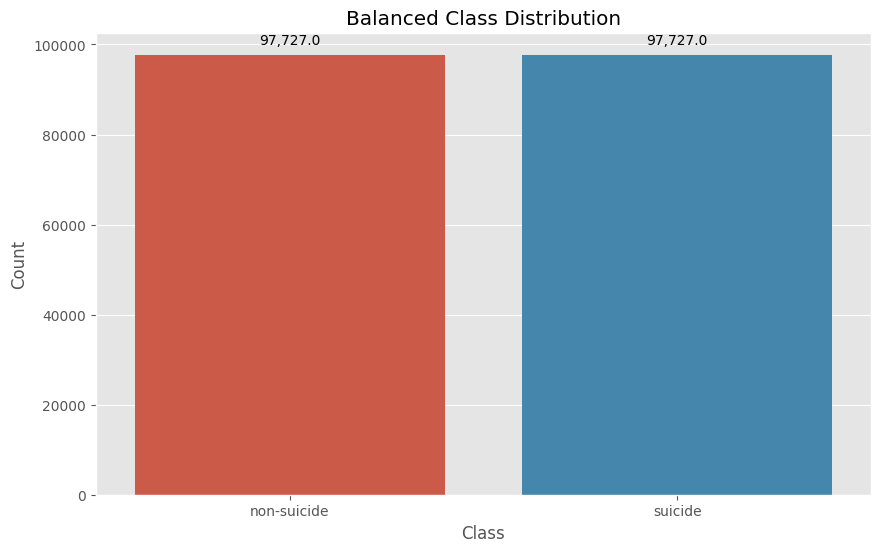

<Figure size 1200x700 with 0 Axes>

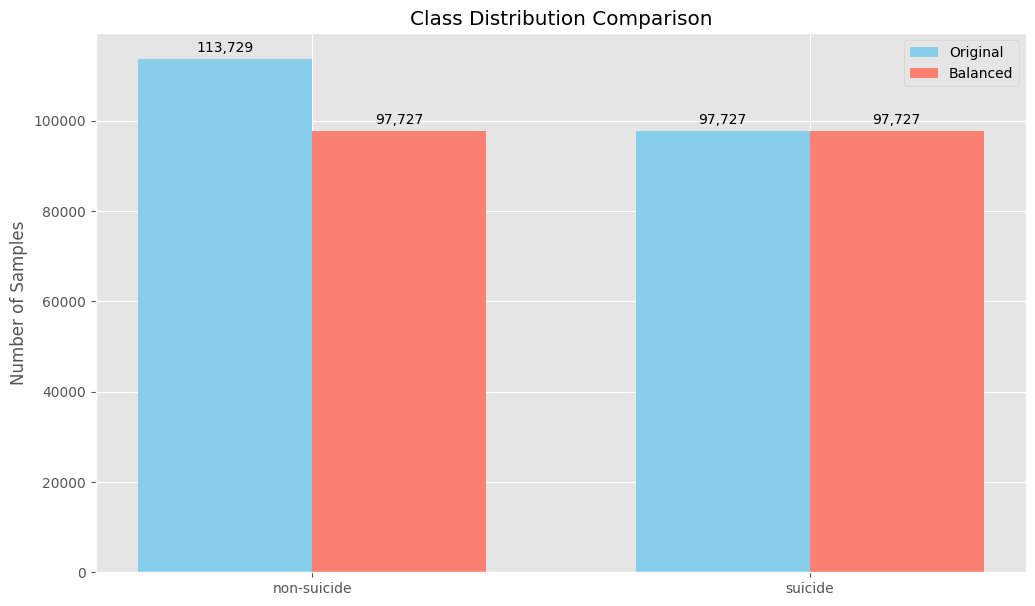

Saved to /kaggle/working/dataset_balancing/suicide_detection_balanced.csv

BALANCING COMPLETED

Original dataset shape: (211468, 3)
Balanced dataset shape: (195454, 3)

Majority class 'non-suicide' was downsampled from 113729 to 97727 samples
Minority class 'suicide' remained at 97727 samples

Balanced dataset saved to: /kaggle/working/dataset_balancing/suicide_detection_balanced.csv

Generated visualization files:
- /kaggle/working/dataset_balancing/01_original_class_distribution.png
- /kaggle/working/dataset_balancing/02_balanced_class_distribution.png
- /kaggle/working/dataset_balancing/03_distribution_comparison.png


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# For visualization
plt.style.use('ggplot')

# Set paths
input_file_path = '/kaggle/input/suicide-detection-preprocessed/suicide_detection_preprocessed.csv'
output_directory = '/kaggle/working/'

# Set specific output folder name
results_dir = f"{output_directory}dataset_balancing/"

# Create directory if it doesn't exist
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
else:
    # If directory already exists, clean it by removing existing files (optional)
    print(f"Directory {results_dir} already exists. Files may be overwritten.")

# Function to save and display figures
def save_and_display_figure(fig, filename):
    """Save matplotlib figure to PNG file and display it in the notebook"""
    # Save in results directory
    filepath = f"{results_dir}{filename}.png"
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    
    # Display in notebook
    plt.show()
    
    # Return filepath for reference
    return filepath

# Function to save data files
def save_data_file(df, filename):
    """Save dataframe to CSV file in the results directory"""
    # Remove any unnamed columns before saving
    df_to_save = df.copy()
    unnamed_cols = [col for col in df_to_save.columns if 'Unnamed:' in col]
    if unnamed_cols:
        df_to_save = df_to_save.drop(columns=unnamed_cols)
    
    # Save in results directory
    filepath = f"{results_dir}{filename}.csv"
    df_to_save.to_csv(filepath, index=False)
    print(f"Saved to {filepath}")
    
    # Return filepath for reference
    return filepath

# Print header
print("=" * 80)
print("DATASET BALANCING")
print("=" * 80)

# Load preprocessed dataset
print("Loading preprocessed dataset...")
try:
    # First try with UTF-8 encoding
    df = pd.read_csv(input_file_path, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 encoding failed, trying with latin-1 encoding...")
    try:
        # Try with latin-1 encoding (which can handle most byte sequences)
        df = pd.read_csv(input_file_path, encoding='latin-1')
        print("Successfully loaded with latin-1 encoding")
    except Exception as e:
        # If that fails, try with 'ISO-8859-1' encoding
        print(f"latin-1 encoding failed: {e}")
        print("Trying with ISO-8859-1 encoding...")
        try:
            df = pd.read_csv(input_file_path, encoding='ISO-8859-1')
            print("Successfully loaded with ISO-8859-1 encoding")
        except Exception as e:
            print(f"ISO-8859-1 encoding failed: {e}")
            print("Trying with cp1252 encoding (Windows default)...")
            df = pd.read_csv(input_file_path, encoding='cp1252')
            print("Successfully loaded with cp1252 encoding")

# Remove any unwanted columns
unnamed_cols = [col for col in df.columns if 'Unnamed:' in col]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Display info about the loaded data
print(f"Dataset loaded with shape: {df.shape}")
print("First few rows:")
print(df.head())

# Check the class distribution before balancing
class_counts = df['class'].value_counts()
print("\nClass distribution before balancing:")
print(class_counts)

# Plot original class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='class', data=df)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

# Save and display figure
save_and_display_figure(plt.gcf(), "01_original_class_distribution")

# Balance the dataset by downsampling the majority class
print("\nBalancing the dataset...")
df_majority = df[df['class'] == class_counts.idxmax()]
df_minority = df[df['class'] == class_counts.idxmin()]

# Print info about class sizes
print(f"Majority class '{class_counts.idxmax()}': {len(df_majority)} samples")
print(f"Minority class '{class_counts.idxmin()}': {len(df_minority)} samples")

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Combine the downsampled majority class with the minority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the balanced class distribution
balanced_class_counts = df_balanced['class'].value_counts()
print("\nClass distribution after balancing:")
print(balanced_class_counts)

# Plot balanced class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='class', data=df_balanced)
plt.title('Balanced Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

# Save and display figure
save_and_display_figure(plt.gcf(), "02_balanced_class_distribution")

# Create a comparison of before and after balancing
plt.figure(figsize=(12, 7))

# Data for plotting
datasets = ['Original', 'Balanced']
original_counts = [class_counts.get(class_name, 0) for class_name in class_counts.index]
balanced_counts = [balanced_class_counts.get(class_name, 0) for class_name in class_counts.index]

# Set up side-by-side bar chart
x = np.arange(len(class_counts.index))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
original_bars = ax.bar(x - width/2, original_counts, width, label='Original', color='skyblue')
balanced_bars = ax.bar(x + width/2, balanced_counts, width, label='Balanced', color='salmon')

ax.set_title('Class Distribution Comparison')
ax.set_ylabel('Number of Samples')
ax.set_xticks(x)
ax.set_xticklabels(class_counts.index)
ax.legend()

# Add count labels on bars
for bars in [original_bars, balanced_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height):,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Save and display figure
save_and_display_figure(plt.gcf(), "03_distribution_comparison")

# Save the balanced data
balanced_file_path = save_data_file(df_balanced, "suicide_detection_balanced")

# Print final summary
print("\n" + "=" * 80)
print("BALANCING COMPLETED")
print("=" * 80)
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Balanced dataset shape: {df_balanced.shape}")
print(f"\nMajority class '{class_counts.idxmax()}' was downsampled from {len(df_majority)} to {len(df_minority)} samples")
print(f"Minority class '{class_counts.idxmin()}' remained at {len(df_minority)} samples")
print(f"\nBalanced dataset saved to: {balanced_file_path}")
print("\nGenerated visualization files:")
for i in range(1, 4):
    filename = f"{i:02d}_{'original_class_distribution' if i==1 else 'balanced_class_distribution' if i==2 else 'distribution_comparison'}"
    print(f"- {results_dir}{filename}.png")

MODEL VALIDATION SETUP

Loading balanced dataset...
Successfully loaded with utf-8 encoding

Dataset loaded with shape: (195454, 3)

Columns in the dataset:
['text', 'class', 'cleaned_text']

First few rows:
                                                text        class  \
0  remind me to never write research papers for a...  non-suicide   
1  Help me Okay, so have a HUGE crush on someone....  non-suicide   
2  Gif pfps are no more Where you were when gif p...  non-suicide   
3  Goodbye everyone!Alas, the day has come! I don...      suicide   
4  GIRLS ONLY, GUYS GET OUT Now that the horny gu...  non-suicide   

                                        cleaned_text  
0  remind never write research paper living term ...  
1  help okay huge crush not talk though time clos...  
2  pop no pop stop move home eat dorito phone rin...  
3  goodbye alas day come not feel super upset lit...  
4  girl guy horny guy not hate pee think cock pan...  

Class distribution:
class
non-suicide    97727

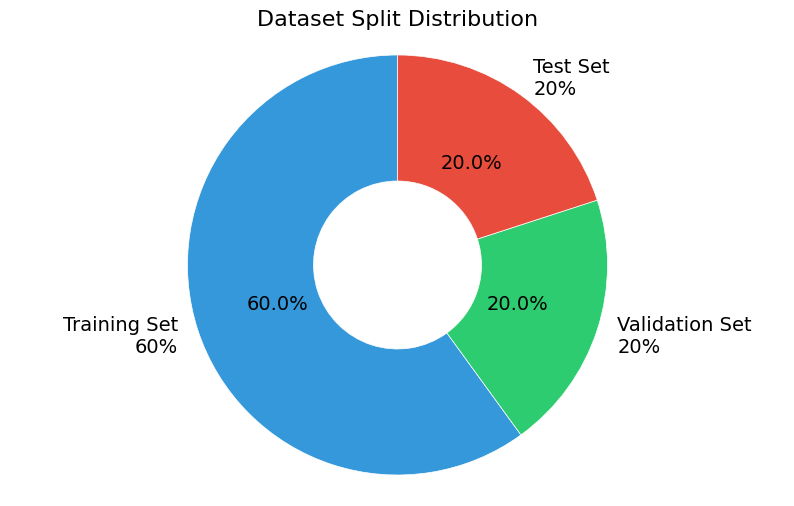


Setting up 5-fold cross-validation on the training set...


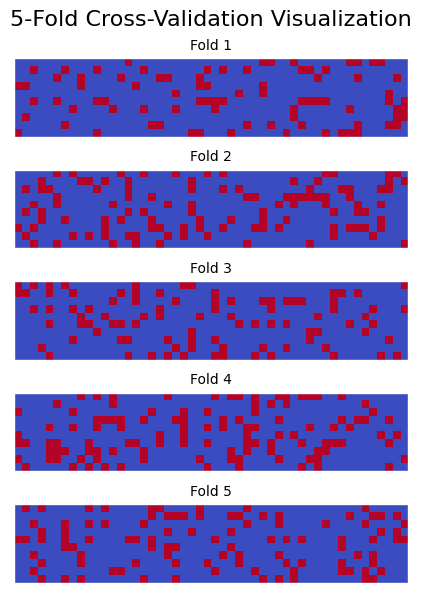


Saving train/validation/test splits to CSV files...
Saved to /kaggle/working/Model Validation Setup/train_set.csv
Saved to /kaggle/working/Model Validation Setup/validation_set.csv
Saved to /kaggle/working/Model Validation Setup/test_set.csv

K-fold splits can be saved to disk if needed.
To save the k-fold splits, you can call the save_kfold_splits() function.

VALIDATION SETUP COMPLETED

Summary:
1. Loaded balanced dataset with 195454 samples
2. Created train/validation/test split (60/20/20)
   - Training set: 117272 samples
   - Validation set: 39091 samples
   - Test set: 39091 samples
3. Set up 5-fold cross-validation on the training set

Saved files:
- Training set: /kaggle/working/Model Validation Setup/train_set.csv
- Validation set: /kaggle/working/Model Validation Setup/validation_set.csv
- Test set: /kaggle/working/Model Validation Setup/test_set.csv
- Dataset split visualization: /kaggle/working/Model Validation Setup/dataset_split_distribution.png
- K-fold visualization: /

'\n# Example code for TF-IDF feature extraction\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Create a TF-IDF vectorizer\ntfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)\n\n# Fit and transform the training data\nX_train_tfidf = tfidf_vectorizer.fit_transform(X_train)\n\n# Transform validation and test data\nX_val_tfidf = tfidf_vectorizer.transform(X_val)\nX_test_tfidf = tfidf_vectorizer.transform(X_test)\n'

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# Set paths
input_file_path = '/kaggle/working/dataset_balancing/suicide_detection_balanced.csv'
output_directory = '/kaggle/working/Model Validation Setup/'

# Make sure output directory exists
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Function to save and display figures
def save_and_display_figure(fig, filename):
    """Save matplotlib figure to PNG file and display it in the notebook"""
    filepath = f"{output_directory}{filename}.png"
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    return filepath

# Function to save data files without displaying
def save_data_file(df, filename):
    """Save dataframe to CSV file"""
    # Remove any unnamed columns before saving
    df_to_save = df.copy()
    unnamed_cols = [col for col in df_to_save.columns if 'Unnamed:' in col]
    if unnamed_cols:
        df_to_save = df_to_save.drop(columns=unnamed_cols)
    
    filepath = f"{output_directory}{filename}.csv"
    df_to_save.to_csv(filepath, index=False)
    print(f"Saved to {filepath}")
    return filepath

# Print header
print("=" * 80)
print("MODEL VALIDATION SETUP")
print("=" * 80)

# Load balanced dataset
print("\nLoading balanced dataset...")
try:
    # Try different encodings
    for encoding in ['utf-8', 'latin-1', 'ISO-8859-1', 'cp1252']:
        try:
            df = pd.read_csv(input_file_path, encoding=encoding)
            print(f"Successfully loaded with {encoding} encoding")
            break
        except UnicodeDecodeError:
            print(f"{encoding} encoding failed, trying next...")
        except Exception as e:
            print(f"Error with {encoding} encoding: {e}")
except Exception as e:
    print(f"Failed to load the dataset: {e}")
    raise

# Remove any unwanted columns
unnamed_cols = [col for col in df.columns if 'Unnamed:' in col]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Display info about the loaded data
print(f"\nDataset loaded with shape: {df.shape}")
print("\nColumns in the dataset:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Check class distribution
class_counts = df['class'].value_counts()
print("\nClass distribution:")
print(class_counts)

# Prepare features and target
print("\nPreparing features (X) and target (y)...")

# Identify feature columns (assuming 'text' and 'cleaned_text' are available)
if 'cleaned_text' in df.columns:
    text_column = 'cleaned_text'
elif 'text' in df.columns:
    text_column = 'text'
else:
    text_columns = [col for col in df.columns if 'text' in col.lower()]
    if text_columns:
        text_column = text_columns[0]
    else:
        raise ValueError("Could not identify a text column in the dataset")

print(f"Using '{text_column}' as the text feature")

# Split into features and target
X = df[text_column]
y = df['class']

# Convert target to binary if needed
unique_classes = y.unique()
if len(unique_classes) == 2:
    print(f"\nTarget classes: {unique_classes}")
    
    # Check if target needs to be converted to numeric
    if not pd.api.types.is_numeric_dtype(y):
        print("Converting target to numeric (0/1)...")
        # Create a mapping for class labels
        class_mapping = {class_label: idx for idx, class_label in enumerate(unique_classes)}
        y = y.map(class_mapping)
        print(f"Class mapping: {class_mapping}")

# Step 1: Initial Train-Test Split (80% train+val, 20% test)
print("\nStep 1: Splitting data into 80% train+validation and 20% test set...")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split the temp set into training and validation (75% train, 25% val out of the 80%)
# This results in an overall 60% train, 20% validation, 20% test split
print("Step 2: Further splitting into 60% train and 20% validation set...")
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Print split sizes
print(f"\nTraining set size: {len(X_train)} ({len(X_train)/len(X):.1%} of total)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X):.1%} of total)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X):.1%} of total)")

# Create a visualization of the split
plt.figure(figsize=(10, 6))
split_sizes = [len(X_train), len(X_val), len(X_test)]
split_labels = ['Training Set\n60%', 'Validation Set\n20%', 'Test Set\n20%']
colors = ['#3498db', '#2ecc71', '#e74c3c']

plt.pie(split_sizes, labels=split_labels, autopct='%1.1f%%', startangle=90, colors=colors,
        wedgeprops={'edgecolor': 'white', 'width': 0.6}, textprops={'fontsize': 14})
plt.title('Dataset Split Distribution', fontsize=16)
plt.axis('equal')

save_and_display_figure(plt.gcf(), "dataset_split_distribution")

# Set up K-Fold Cross-Validation
k = 5  # Number of folds
print(f"\nSetting up {k}-fold cross-validation on the training set...")

# Use StratifiedKFold to maintain class balance in each fold
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Create a visualization of the K-fold process
plt.figure(figsize=(12, 6))

# Create a sample array just for visualization
sample_array = np.zeros((10, 50))

# Plot K-fold cross-validation
fold_number = 1
for train_idx, val_idx in skf.split(np.zeros(len(y_train)), y_train):
    # Plot train indices
    for i in range(10):
        for j in range(50):
            idx = i * 50 + j
            if idx < len(train_idx) and idx < 500:  # Limit to first 500 samples for visualization
                sample_array[i, j] = 1 if idx in train_idx else 2
    
    # Display the fold
    plt.subplot(k, 1, fold_number)
    plt.imshow(sample_array, cmap=plt.cm.coolwarm, interpolation='nearest')
    plt.title(f'Fold {fold_number}', fontsize=10)
    plt.xticks([])
    plt.yticks([])
    
    fold_number += 1

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle(f'{k}-Fold Cross-Validation Visualization', fontsize=16)

save_and_display_figure(plt.gcf(), "k_fold_visualization")

# Create CSV files for the splits
print("\nSaving train/validation/test splits to CSV files...")

# Create dataframes for each split
train_df = pd.DataFrame({text_column: X_train, 'class': y_train})
val_df = pd.DataFrame({text_column: X_val, 'class': y_val})
test_df = pd.DataFrame({text_column: X_test, 'class': y_test})

# Save each split to a file
train_file = save_data_file(train_df, "train_set")
val_file = save_data_file(val_df, "validation_set")
test_file = save_data_file(test_df, "test_set")

# Create function to save k-fold splits if needed for later
def save_kfold_splits():
    fold = 1
    for train_index, val_index in skf.split(X_train, y_train):
        # Get fold data
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Create dataframes
        fold_train_df = pd.DataFrame({text_column: X_fold_train, 'class': y_fold_train})
        fold_val_df = pd.DataFrame({text_column: X_fold_val, 'class': y_fold_val})
        
        # Save to files
        save_data_file(fold_train_df, f"fold_{fold}_train")
        save_data_file(fold_val_df, f"fold_{fold}_val")
        
        fold += 1
    
    return fold - 1

# Ask if the user wants to save the k-fold splits
print(f"\nK-fold splits can be saved to disk if needed.")
print("To save the k-fold splits, you can call the save_kfold_splits() function.")

# Print summary
print("\n" + "=" * 80)
print("VALIDATION SETUP COMPLETED")
print("=" * 80)
print("\nSummary:")
print(f"1. Loaded balanced dataset with {df.shape[0]} samples")
print(f"2. Created train/validation/test split (60/20/20)")
print(f"   - Training set: {len(X_train)} samples")
print(f"   - Validation set: {len(X_val)} samples")
print(f"   - Test set: {len(X_test)} samples")
print(f"3. Set up {k}-fold cross-validation on the training set")
print("\nSaved files:")
print(f"- Training set: {train_file}")
print(f"- Validation set: {val_file}")
print(f"- Test set: {test_file}")
print(f"- Dataset split visualization: {output_directory}dataset_split_distribution.png")
print(f"- K-fold visualization: {output_directory}k_fold_visualization.png")

print("\nNext steps for your machine learning workflow:")
print("1. Feature extraction from text (TF-IDF, Word2Vec, embeddings, etc.)")
print("2. Model training using the training set")
print("3. Hyperparameter tuning using cross-validation and validation set")
print("4. Final evaluation on the test set")
print("5. Model deployment")

# Optional code for feature extraction (commented out as placeholder for future use)
"""
# Example code for TF-IDF feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform validation and test data
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
"""

LOGISTIC REGRESSION MODEL FOR SUICIDE DETECTION

Loading datasets...
Successfully loaded datasets with utf-8 encoding

Training set shape: (117272, 2)
Validation set shape: (39091, 2)
Test set shape: (39091, 2)

Using 'cleaned_text' as the text feature

Performing TF-IDF feature extraction...
TF-IDF parameters: {'max_features': 10000, 'min_df': 2, 'max_df': 0.8, 'ngram_range': (1, 2)}
Saved tfidf_vectorizer to /kaggle/working/Logistic Regression/tfidf_vectorizer.pkl

Feature extraction complete in 26.55 seconds
Number of features: 10000

Top 20 features by TF-IDF score:
  not: 7645.2228
  but: 3836.9601
  want: 3778.0662
  like: 3296.3675
  feel: 3026.5211
  know: 2918.5507
  go: 2403.4134
  life: 2307.8127
  think: 2292.4653
  no: 2260.7677
  people: 2031.7188
  time: 1937.8446
  friend: 1914.2472
  get: 1876.3983
  day: 1866.7336
  help: 1825.8288
  not know: 1758.2869
  good: 1678.2012
  year: 1673.2510
  try: 1649.1140


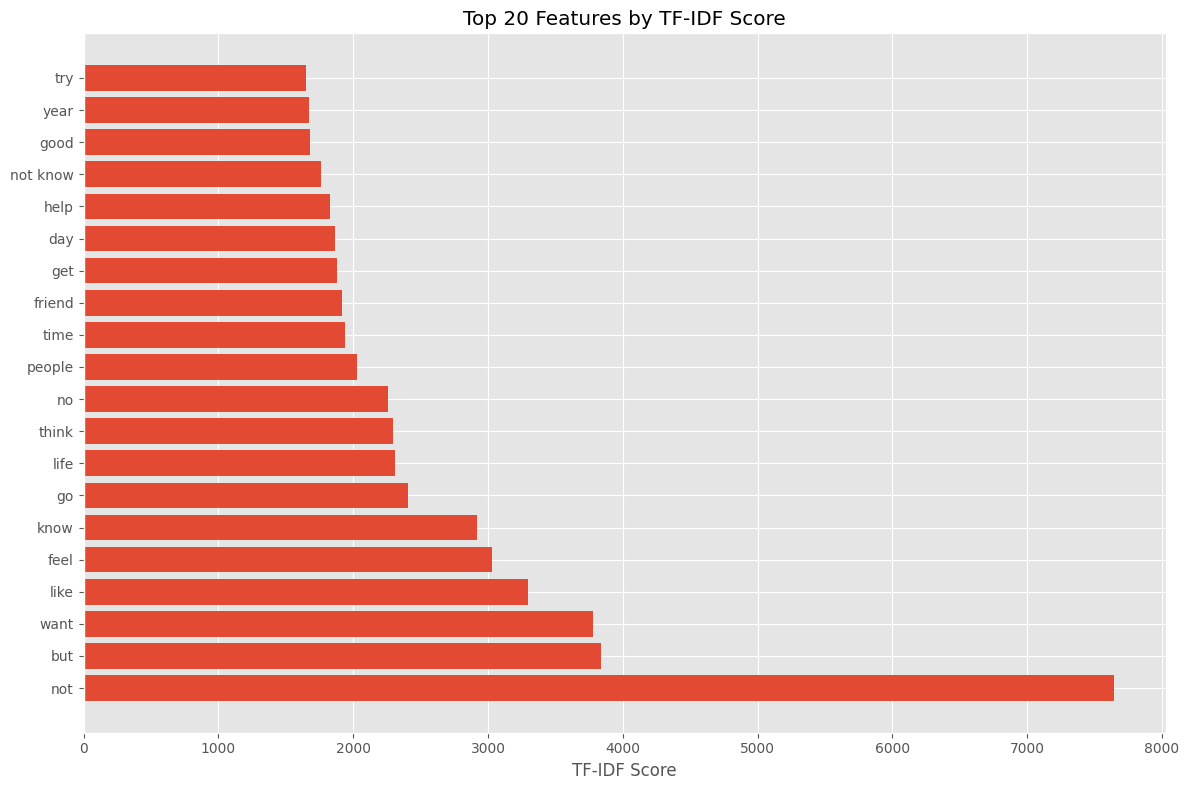


Performing hyperparameter tuning for Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Hyperparameter tuning complete in 94.64 seconds
Best parameters: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.9255
Saved logistic_regression_model to /kaggle/working/Logistic Regression/logistic_regression_model.pkl

Evaluating model on validation set...
Validation Accuracy: 0.9262
Validation Precision: 0.9335
Validation Recall: 0.9178
Validation F1 Score: 0.9256


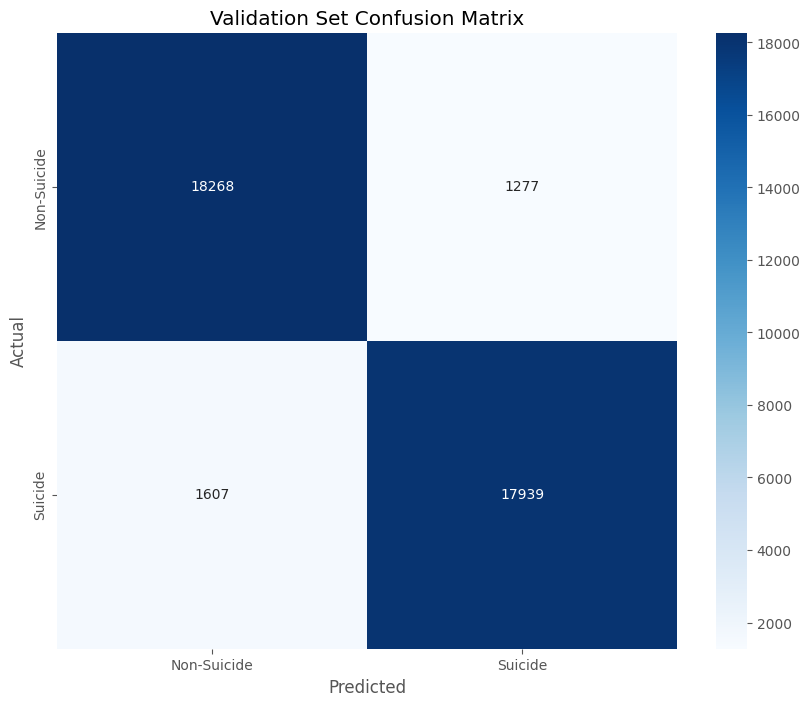

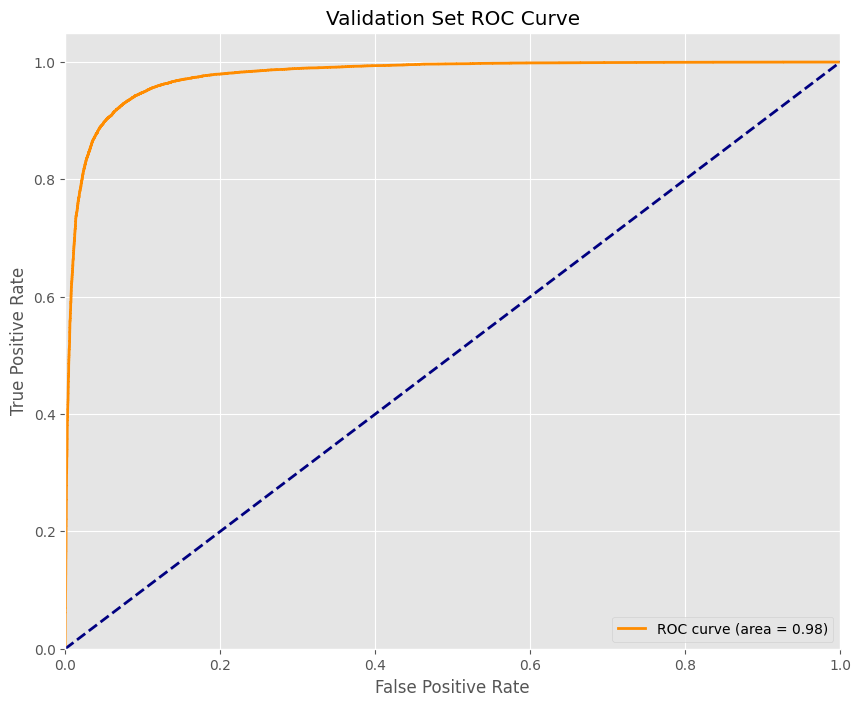


Performing final evaluation on test set...
Test Accuracy: 0.9278
Test Precision: 0.9347
Test Recall: 0.9198
Test F1 Score: 0.9272

Classification Report:
              precision    recall  f1-score   support

 Non-Suicide       0.92      0.94      0.93     19546
     Suicide       0.93      0.92      0.93     19545

    accuracy                           0.93     39091
   macro avg       0.93      0.93      0.93     39091
weighted avg       0.93      0.93      0.93     39091



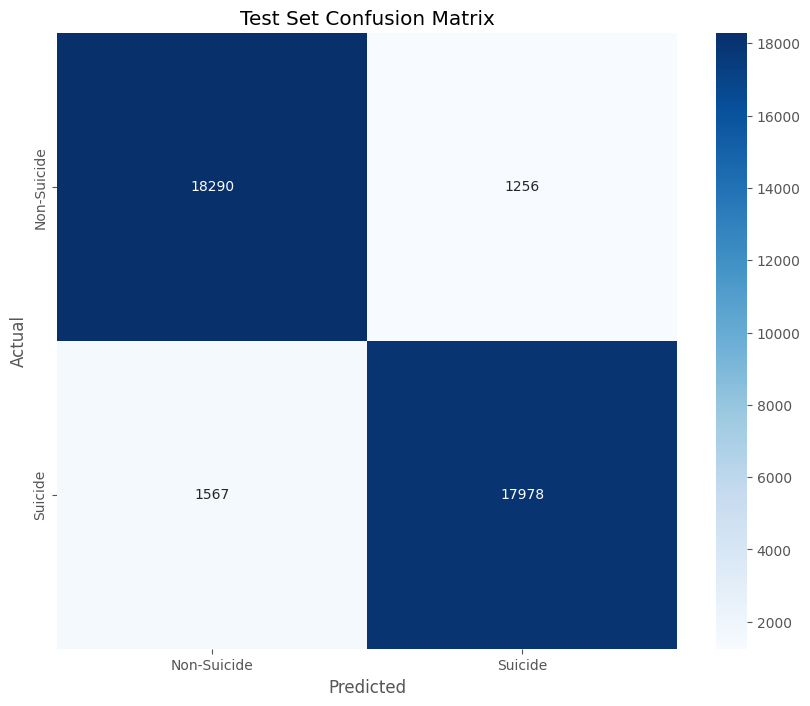

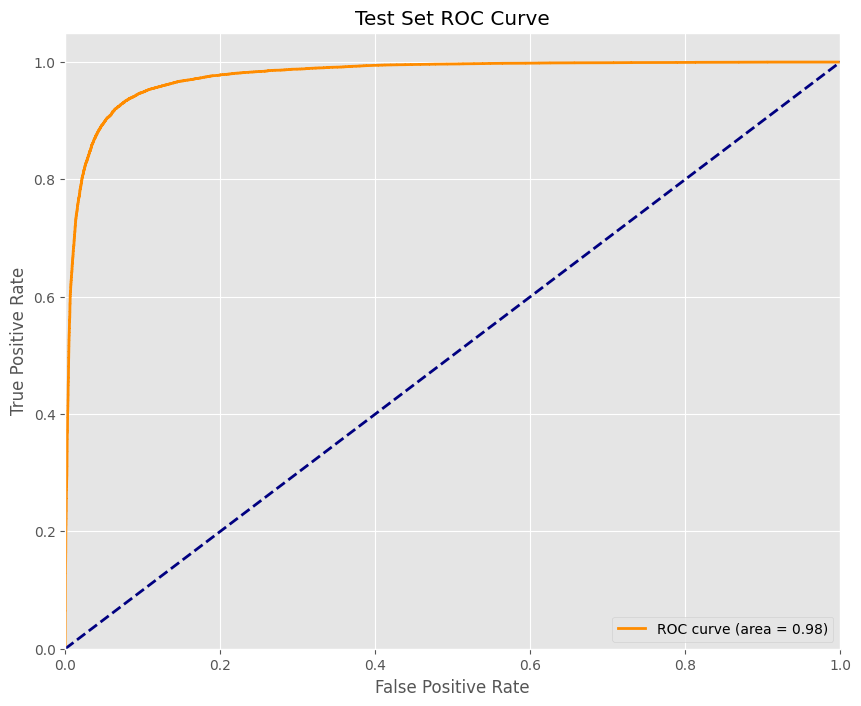

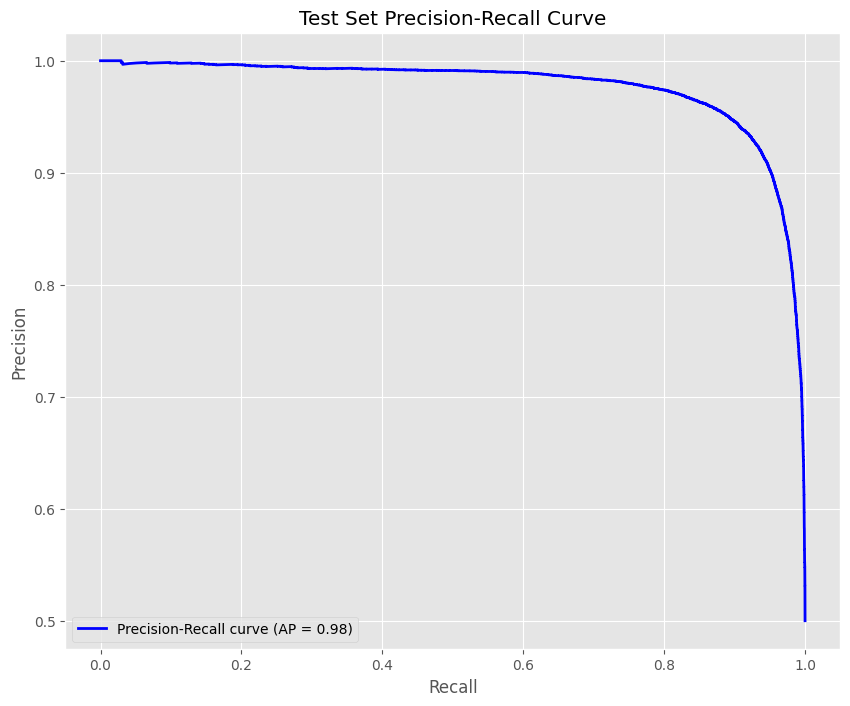


Analyzing feature importance...


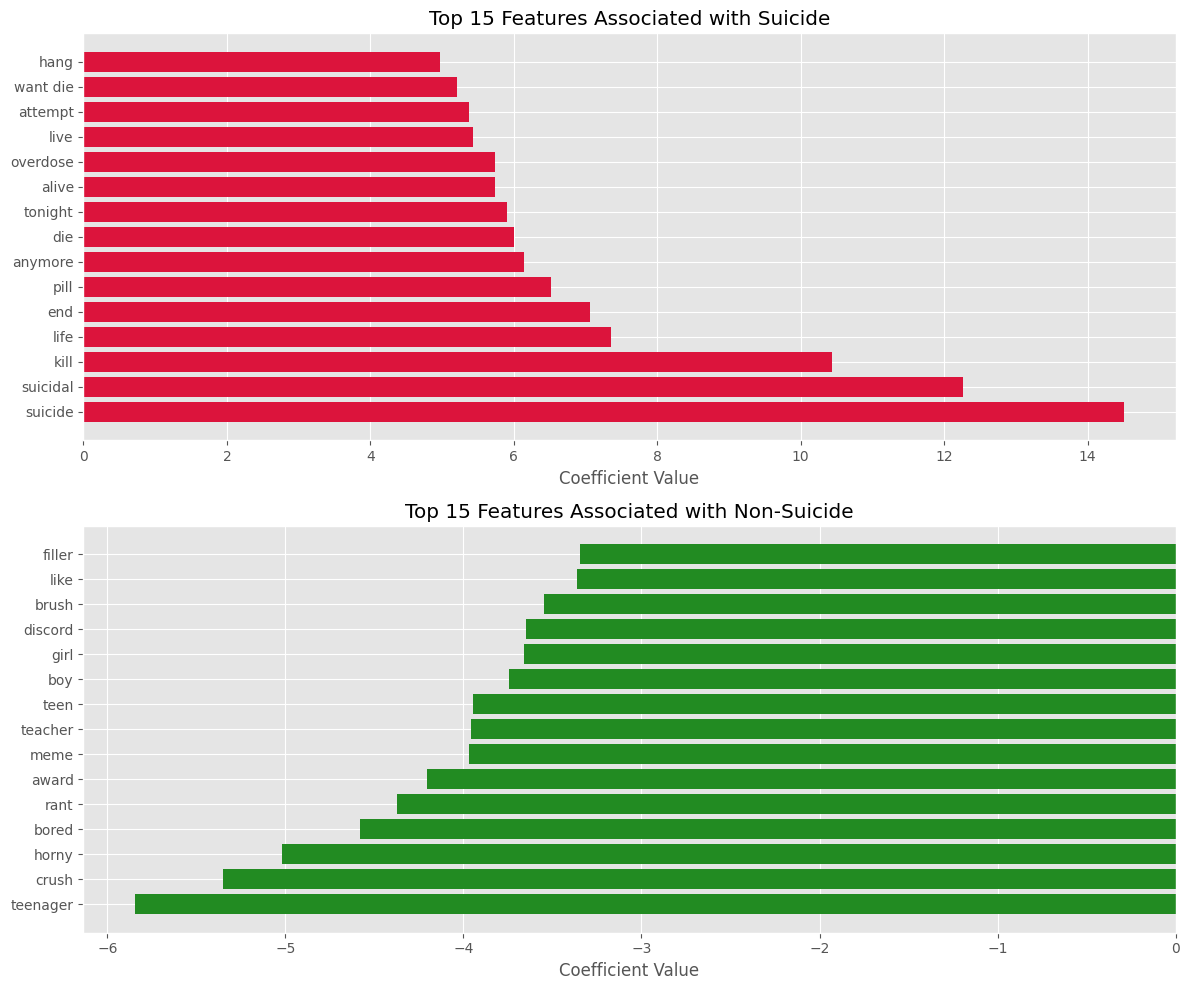

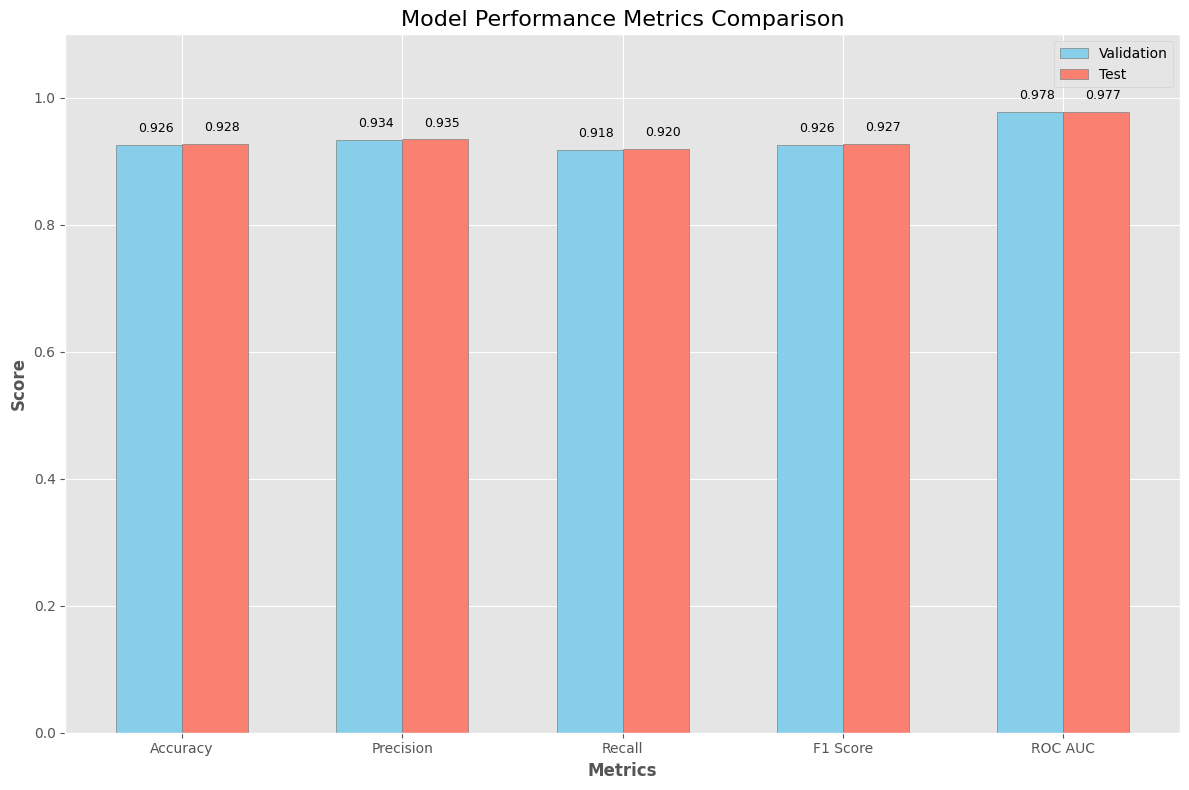


LOGISTIC REGRESSION MODEL TRAINING COMPLETED

Summary of Results:
Model: Logistic Regression with {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

Validation Metrics:
- Accuracy: 0.9262
- Precision: 0.9335
- Recall: 0.9178
- F1 Score: 0.9256
- ROC AUC: 0.9776

Test Metrics:
- Accuracy: 0.9278
- Precision: 0.9347
- Recall: 0.9198
- F1 Score: 0.9272
- ROC AUC: 0.9774

All results and files have been saved to: /kaggle/working/Logistic Regression/

Files saved:
- Model: logistic_regression_model.pkl
- TF-IDF vectorizer: tfidf_vectorizer.pkl
- Classification report: classification_report.txt
- Feature importance: feature_importance.csv
- Model results: model_results.json
- Visualizations: confusion matrices, ROC curves, feature importance plots, etc.


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import GridSearchCV
import os
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set paths
train_path = '/kaggle/working/Model Validation Setup/train_set.csv'
val_path = '/kaggle/working/Model Validation Setup/validation_set.csv'
test_path = '/kaggle/working/Model Validation Setup/test_set.csv'
output_dir = '/kaggle/working/Logistic Regression/'

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Function to save and display figures
def save_and_display_figure(fig, filename):
    """Save matplotlib figure to PNG file and display it in the notebook"""
    filepath = f"{output_dir}{filename}.png"
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    return filepath

# Function to save models and vectorizers
def save_model(model, filename):
    """Save model or vectorizer to file"""
    filepath = f"{output_dir}{filename}.pkl"
    joblib.dump(model, filepath)
    print(f"Saved {filename} to {filepath}")
    return filepath

# Print header
print("=" * 80)
print("LOGISTIC REGRESSION MODEL FOR SUICIDE DETECTION")
print("=" * 80)

# Load datasets
print("\nLoading datasets...")
try:
    # Try different encodings to be safe
    for encoding in ['utf-8', 'latin-1', 'ISO-8859-1', 'cp1252']:
        try:
            train_df = pd.read_csv(train_path, encoding=encoding)
            val_df = pd.read_csv(val_path, encoding=encoding)
            test_df = pd.read_csv(test_path, encoding=encoding)
            print(f"Successfully loaded datasets with {encoding} encoding")
            break
        except UnicodeDecodeError:
            print(f"{encoding} encoding failed, trying next...")
        except Exception as e:
            print(f"Error with {encoding} encoding: {e}")
except Exception as e:
    print(f"Failed to load datasets: {e}")
    raise

# Display dataset shapes
print(f"\nTraining set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

# Identify text and target columns
if 'cleaned_text' in train_df.columns:
    text_col = 'cleaned_text'
elif 'text' in train_df.columns:
    text_col = 'text'
else:
    text_cols = [col for col in train_df.columns if 'text' in col.lower()]
    if text_cols:
        text_col = text_cols[0]
    else:
        raise ValueError("Could not identify a text column in the dataset")

print(f"\nUsing '{text_col}' as the text feature")

# Check if target needs to be numeric
if not pd.api.types.is_numeric_dtype(train_df['class']):
    print("\nConverting target class to numeric...")
    # Create mapping for class labels
    class_mapping = {label: idx for idx, label in enumerate(train_df['class'].unique())}
    inverse_mapping = {idx: label for label, idx in class_mapping.items()}
    
    # Convert classes to numeric
    train_df['class_numeric'] = train_df['class'].map(class_mapping)
    val_df['class_numeric'] = val_df['class'].map(class_mapping)
    test_df['class_numeric'] = test_df['class'].map(class_mapping)
    
    print(f"Class mapping: {class_mapping}")
    target_col = 'class_numeric'
else:
    target_col = 'class'
    inverse_mapping = {0: "Non-Suicide", 1: "Suicide"}

# Extract features and targets
X_train = train_df[text_col]
y_train = train_df[target_col]
X_val = val_df[text_col]
y_val = val_df[target_col]
X_test = test_df[text_col]
y_test = test_df[target_col]

# Feature Extraction with TF-IDF
print("\nPerforming TF-IDF feature extraction...")
tfidf_params = {
    'max_features': 10000,    # Maximum number of features
    'min_df': 2,              # Minimum document frequency
    'max_df': 0.8,            # Maximum document frequency
    'ngram_range': (1, 2)     # Include unigrams and bigrams
}

print(f"TF-IDF parameters: {tfidf_params}")
tfidf_vectorizer = TfidfVectorizer(**tfidf_params)

# Fit and transform training data
start_time = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Save the vectorizer
save_model(tfidf_vectorizer, "tfidf_vectorizer")

# Print feature extraction information
print(f"\nFeature extraction complete in {time.time() - start_time:.2f} seconds")
print(f"Number of features: {X_train_tfidf.shape[1]}")

# Display most important features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 20 features by TF-IDF score:")

# Get the sum of TF-IDF values for each term across all documents
tfidf_sums = X_train_tfidf.sum(axis=0).A1
top_indices = np.argsort(tfidf_sums)[-20:][::-1]
top_features = [(feature_names[idx], tfidf_sums[idx]) for idx in top_indices]

for feature, score in top_features:
    print(f"  {feature}: {score:.4f}")

# Visualize top features
plt.figure(figsize=(12, 8))
features, scores = zip(*top_features)
plt.barh(range(len(features)), scores, align='center')
plt.yticks(range(len(features)), features)
plt.xlabel('TF-IDF Score')
plt.title('Top 20 Features by TF-IDF Score')
plt.tight_layout()
save_and_display_figure(plt.gcf(), "top_tfidf_features")

# Hyperparameter Tuning
print("\nPerforming hyperparameter tuning for Logistic Regression...")
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2'],       # Regularization type
    'solver': ['liblinear'],       # Solver (liblinear supports both l1 and l2)
    'class_weight': [None, 'balanced']  # Class weights
}

# Create base model
base_model = LogisticRegression(random_state=42, max_iter=1000)

# Set up grid search with cross-validation
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='f1',        # Optimize for F1 score
    n_jobs=-1,           # Use all available CPU cores
    verbose=1
)

# Fit grid search
start_time = time.time()
grid_search.fit(X_train_tfidf, y_train)
tuning_time = time.time() - start_time

# Get best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\nHyperparameter tuning complete in {tuning_time:.2f} seconds")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Save the best model
save_model(best_model, "logistic_regression_model")

# Evaluate on validation set
print("\nEvaluating model on validation set...")
y_val_pred = best_model.predict(X_val_tfidf)
y_val_proba = best_model.predict_proba(X_val_tfidf)[:, 1]

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")
print(f"Validation F1 Score: {val_f1:.4f}")

# Generate confusion matrix for validation set
val_cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[inverse_mapping[0], inverse_mapping[1]],
            yticklabels=[inverse_mapping[0], inverse_mapping[1]])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Validation Set Confusion Matrix')
save_and_display_figure(plt.gcf(), "validation_confusion_matrix")

# Generate ROC curve for validation set
val_fpr, val_tpr, _ = roc_curve(y_val, y_val_proba)
val_roc_auc = auc(val_fpr, val_tpr)

plt.figure(figsize=(10, 8))
plt.plot(val_fpr, val_tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {val_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation Set ROC Curve')
plt.legend(loc="lower right")
save_and_display_figure(plt.gcf(), "validation_roc_curve")

# Final evaluation on test set
print("\nPerforming final evaluation on test set...")
y_test_pred = best_model.predict(X_test_tfidf)
y_test_proba = best_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Generate detailed classification report
print("\nClassification Report:")
report = classification_report(y_test, y_test_pred, target_names=[inverse_mapping[0], inverse_mapping[1]])
print(report)

# Save classification report to file
with open(f"{output_dir}classification_report.txt", "w") as f:
    f.write("CLASSIFICATION REPORT\n")
    f.write("=" * 80 + "\n\n")
    f.write(report)

# Generate confusion matrix for test set
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[inverse_mapping[0], inverse_mapping[1]],
            yticklabels=[inverse_mapping[0], inverse_mapping[1]])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Set Confusion Matrix')
save_and_display_figure(plt.gcf(), "test_confusion_matrix")

# Generate ROC curve for test set
test_fpr, test_tpr, _ = roc_curve(y_test, y_test_proba)
test_roc_auc = auc(test_fpr, test_tpr)

plt.figure(figsize=(10, 8))
plt.plot(test_fpr, test_tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {test_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set ROC Curve')
plt.legend(loc="lower right")
save_and_display_figure(plt.gcf(), "test_roc_curve")

# Generate precision-recall curve
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
test_avg_precision = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(10, 8))
plt.plot(test_recall_curve, test_precision_curve, color='blue', lw=2,
         label=f'Precision-Recall curve (AP = {test_avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Test Set Precision-Recall Curve')
plt.legend(loc="lower left")
save_and_display_figure(plt.gcf(), "test_precision_recall_curve")

# Analyze feature importance
print("\nAnalyzing feature importance...")
if hasattr(best_model, 'coef_'):
    # Get feature importance from model coefficients
    coef = best_model.coef_[0]
    # Get feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Create DataFrame of feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': coef
    })
    
    # Sort by absolute importance
    feature_importance['Abs_Importance'] = np.abs(feature_importance['Importance'])
    feature_importance = feature_importance.sort_values('Abs_Importance', ascending=False)
    
    # Save feature importance to file
    feature_importance.head(100).to_csv(f"{output_dir}feature_importance.csv", index=False)
    
    # Plot top positive and negative features
    top_n = 15
    
    plt.figure(figsize=(12, 10))
    
    # Top positive features (associated with suicide)
    top_positive = feature_importance[feature_importance['Importance'] > 0].head(top_n)
    plt.subplot(2, 1, 1)
    plt.barh(range(len(top_positive)), top_positive['Importance'], align='center', color='crimson')
    plt.yticks(range(len(top_positive)), top_positive['Feature'])
    plt.title(f'Top {top_n} Features Associated with Suicide')
    plt.xlabel('Coefficient Value')
    
    # Top negative features (associated with non-suicide)
    top_negative = feature_importance[feature_importance['Importance'] < 0].head(top_n)
    plt.subplot(2, 1, 2)
    plt.barh(range(len(top_negative)), top_negative['Importance'], align='center', color='forestgreen')
    plt.yticks(range(len(top_negative)), top_negative['Feature'])
    plt.title(f'Top {top_n} Features Associated with Non-Suicide')
    plt.xlabel('Coefficient Value')
    
    plt.tight_layout()
    save_and_display_figure(plt.gcf(), "feature_importance")

# Generate a results summary
results = {
    'Model': 'Logistic Regression',
    'Best Parameters': best_params,
    'Metrics': {
        'Validation': {
            'Accuracy': val_accuracy,
            'Precision': val_precision,
            'Recall': val_recall,
            'F1 Score': val_f1,
            'ROC AUC': val_roc_auc
        },
        'Test': {
            'Accuracy': test_accuracy,
            'Precision': test_precision,
            'Recall': test_recall,
            'F1 Score': test_f1,
            'ROC AUC': test_roc_auc
        }
    }
}

# Save results to file
import json
with open(f"{output_dir}model_results.json", "w") as f:
    json.dump(results, f, indent=4)

# Create a summary visualization
plt.figure(figsize=(12, 8))

# Set up metrics for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
val_scores = [val_accuracy, val_precision, val_recall, val_f1, val_roc_auc]
test_scores = [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]

# Set width of bars
barWidth = 0.3
r1 = np.arange(len(metrics))
r2 = [x + barWidth for x in r1]

# Create grouped bars
plt.bar(r1, val_scores, width=barWidth, label='Validation', color='skyblue', edgecolor='grey')
plt.bar(r2, test_scores, width=barWidth, label='Test', color='salmon', edgecolor='grey')

# Add labels and legend
plt.xlabel('Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.xticks([r + barWidth/2 for r in range(len(metrics))], metrics)
plt.ylim(0, 1.1)
plt.title('Model Performance Metrics Comparison', fontsize=16)
plt.legend()

# Add text labels for each bar
for i, v in enumerate(val_scores):
    plt.text(i - 0.05, v + 0.02, f'{v:.3f}', fontsize=9)
for i, v in enumerate(test_scores):
    plt.text(i + barWidth - 0.05, v + 0.02, f'{v:.3f}', fontsize=9)

plt.tight_layout()
save_and_display_figure(plt.gcf(), "performance_metrics_comparison")

# Print final summary
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION MODEL TRAINING COMPLETED")
print("=" * 80)
print("\nSummary of Results:")
print(f"Model: Logistic Regression with {best_params}")
print(f"\nValidation Metrics:")
print(f"- Accuracy: {val_accuracy:.4f}")
print(f"- Precision: {val_precision:.4f}")
print(f"- Recall: {val_recall:.4f}")
print(f"- F1 Score: {val_f1:.4f}")
print(f"- ROC AUC: {val_roc_auc:.4f}")
print(f"\nTest Metrics:")
print(f"- Accuracy: {test_accuracy:.4f}")
print(f"- Precision: {test_precision:.4f}")
print(f"- Recall: {test_recall:.4f}")
print(f"- F1 Score: {test_f1:.4f}")
print(f"- ROC AUC: {test_roc_auc:.4f}")

print(f"\nAll results and files have been saved to: {output_dir}")
print("\nFiles saved:")
print(f"- Model: logistic_regression_model.pkl")
print(f"- TF-IDF vectorizer: tfidf_vectorizer.pkl")
print(f"- Classification report: classification_report.txt")
print(f"- Feature importance: feature_importance.csv")
print(f"- Model results: model_results.json")
print(f"- Visualizations: confusion matrices, ROC curves, feature importance plots, etc.")